In [1]:
!pip -q install webdataset huggingface_hub

In [2]:
pip install torch-lucent

In [3]:
import torch
import numpy as np
import heapq
from PIL import Image
import matplotlib.pyplot as plt
import os
import webdataset as wds
from lucent.modelzoo import inceptionv1
from lucent.optvis import render, param, transform, objectives

In [5]:
from huggingface_hub import notebook_login
notebook_login()

In [6]:
URLS = "https://huggingface.co/datasets/timm/imagenet-1k-wds/resolve/main/imagenet1k-validation-{0000..0063}.tar"

In [7]:
HF_TOKEN = "_"
os.environ["HF_TOKEN"] = HF_TOKEN
print("HF_TOKEN len:", len(os.environ["HF_TOKEN"]))

HF_TOKEN len: 37


In [8]:
from torch.utils.data import DataLoader
from torchvision import transforms

base = "https://huggingface.co/datasets/timm/imagenet-1k-wds/resolve/main/"
shards = [f"{base}imagenet1k-validation-{i:02d}.tar?download=true" for i in range(64)]

URLS = [
    f"pipe:curl -f -sSL --retry 20 --retry-delay 2 "
    f"-H \"Authorization: Bearer $HF_TOKEN\" "
    f"\"{u}\""
    for u in shards
]

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def to_tensor(sample):
    img = sample.get("jpg") or sample.get("jpeg") or sample.get("JPEG")
    key = sample.get("__key__", "")
    return preprocess(img), key

dataset = (
    wds.WebDataset(URLS, handler=wds.handlers.warn_and_continue)
      .decode("pil", handler=wds.handlers.warn_and_continue)
      .map(to_tensor, handler=wds.handlers.warn_and_continue)
)

dl = DataLoader(dataset, batch_size=64, num_workers=0, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


In [9]:
# Configuration
LAYER_NAME = "mixed4a"
IMAGE_SIZE = 1024
STEPS = 1024
channel = 6

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = inceptionv1(pretrained=True).to(device).eval()


# Param & transforms
def make_param():
    return param.image(
        IMAGE_SIZE,
        fft=True,         # Fourier basis for crispness
        decorrelate=True, # natural color correlations
        channels=3
    )

xforms = [
    transform.jitter(8),
    transform.pad(16, mode="constant", constant_value=0.5),
    transform.random_scale([0.95, 1.0, 1.05]),
    transform.random_rotate([-10, 10]),
]



obj = objectives.channel(LAYER_NAME, channel)

param_f = make_param

images = render.render_vis(
      model, obj,
      param_f=param_f,
      transforms=xforms,
      optimizer=torch.optim.Adam,
      thresholds=(STEPS,),   # run full steps once
      show_image=False
  )

img = images[0][0]
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

# Use mean pixel value as a proxy "score"
score = float(img.mean())

100%|██████████| 512/512 [00:16<00:00, 30.48it/s]


In [31]:
CHANNEL_ID  = 6
REDUCTION   = "max"     # "max" or "mean"
TOPK        = 10
HEAP_BATCH  = 50
CROP_FRAC   = 0.25

activation = {}

def hook_fn(module, inp, out):
    activation["feat"] = out

layer = dict(model.named_modules())[LAYER_NAME]
handle = layer.register_forward_hook(hook_fn)

# Reverse ImageNet normalization for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def tensor_to_pil(x: torch.Tensor) -> Image.Image:
    """x: [3,H,W] or [1,3,H,W], normalized"""
    x = x.detach().cpu()
    if x.dim() == 4:
        x = x[0]
    x = (x * std + mean).clamp(0, 1)
    x = (x.permute(1,2,0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(x)

@torch.no_grad()
def reduce_scores(feat: torch.Tensor, channel_id: int, reduction: str):
    """feat: [B,C,h,w] -> scores: [B]"""
    x = feat[:, channel_id]  # [B,h,w]
    if reduction == "max":
        return x.amax(dim=(1,2))
    elif reduction == "mean":
        return x.mean(dim=(1,2))
    else:
        raise ValueError("REDUCTION must be 'max' or 'mean'")

def crop_from_tensor_and_feat(img_tensor_norm: torch.Tensor,
                              feat_single: torch.Tensor,
                              channel_id: int,
                              frac: float = 0.25) -> Image.Image:

    # de-normalize image for display
    img = (img_tensor_norm.detach().cpu() * std + mean).clamp(0, 1)     # [3,H,W]
    img_np = (img.permute(1,2,0).numpy() * 255).astype(np.uint8)        # [H,W,3]
    H, W = img_np.shape[:2]

    # channel activation map (use positive activations only)
    act = feat_single[channel_id].detach().cpu().clamp(min=0)           # [h,w]
    h, w = act.shape

    # peak in native feature map coordinates
    flat = int(torch.argmax(act).item())
    iy, ix = flat // w, flat % w

    # map that cell center to input pixel coords
    cy = int((iy + 0.5) * H / h)
    cx = int((ix + 0.5) * W / w)

    # fixed-size crop around (cx, cy)
    ch, cw = int(H * frac), int(W * frac)
    y0 = max(0, cy - ch // 2); y1 = min(H, y0 + ch)
    x0 = max(0, cx - cw // 2); x1 = min(W, x0 + cw)

    return Image.fromarray(img_np[y0:y1, x0:x1])

topk = []  # min-heap of (score, key, pil_full, pil_crop)

for step, (imgs, keys) in enumerate(dl):
    imgs = imgs.to(device, non_blocking=True)

    use_cuda = imgs.is_cuda
    with torch.amp.autocast(device_type="cuda", enabled=use_cuda):
        _ = model(imgs)

    feat = activation["feat"]  # [B,C,h,w]

    # score images for this channel
    scores = reduce_scores(feat, CHANNEL_ID, REDUCTION).float().detach().cpu()

    # take only top candidates within this batch
    batch_top = min(HEAP_BATCH, scores.numel())
    vals, idxs = torch.topk(scores, k=batch_top)

    for v, i in zip(vals.tolist(), idxs.tolist()):
        key = keys[i]

        # create PIL using the SAME forward-pass activations
        pil_full = tensor_to_pil(imgs[i])
        pil_crop = crop_from_tensor_and_feat(imgs[i], feat[i], CHANNEL_ID, frac=CROP_FRAC)

        item = (v, key, pil_full, pil_crop)

        if len(topk) < TOPK:
            heapq.heappush(topk, item)
        else:
            if v > topk[0][0]:
                heapq.heapreplace(topk, item)

    if (step + 1) % 50 == 0 and len(topk) > 0:
        print(f"batches={step+1}  current_min_top{TOPK}={topk[0][0]:.4f}")

handle.remove()

top10 = sorted(topk, key=lambda x: x[0], reverse=True)
print([(s, k) for (s, k, _, _) in top10])

TOPK_DIR = "topk_dataset_images"
os.makedirs(TOPK_DIR, exist_ok=True)

for rank, (s, k, pil_full, pil_crop) in enumerate(top10, 1):
    pil_full.save(os.path.join(TOPK_DIR, f"rank{rank:02d}_FULL_score{s:.4f}_key{k}.jpg"))
    pil_crop.save(os.path.join(TOPK_DIR, f"rank{rank:02d}_CROP_score{s:.4f}_key{k}.jpg"))

batches=50  current_min_top10=675.0000
batches=100  current_min_top10=725.0000
batches=150  current_min_top10=779.0000
batches=200  current_min_top10=802.0000
batches=250  current_min_top10=813.0000
batches=300  current_min_top10=875.5000
batches=350  current_min_top10=880.0000
batches=400  current_min_top10=888.5000
batches=450  current_min_top10=897.5000
batches=500  current_min_top10=897.5000
batches=550  current_min_top10=898.5000
batches=600  current_min_top10=898.5000
batches=650  current_min_top10=949.0000
batches=700  current_min_top10=996.0000
batches=750  current_min_top10=1010.0000
[(1279.0, 'ILSVRC2012_val_00035466'), (1216.0, 'ILSVRC2012_val_00036369'), (1179.0, 'ILSVRC2012_val_00042910'), (1083.0, 'ILSVRC2012_val_00028634'), (1069.0, 'ILSVRC2012_val_00024379'), (1060.0, 'ILSVRC2012_val_00028132'), (1032.0, 'ILSVRC2012_val_00016647'), (1030.0, 'ILSVRC2012_val_00031381'), (1014.0, 'ILSVRC2012_val_00019916'), (1010.0, 'ILSVRC2012_val_00012445')]


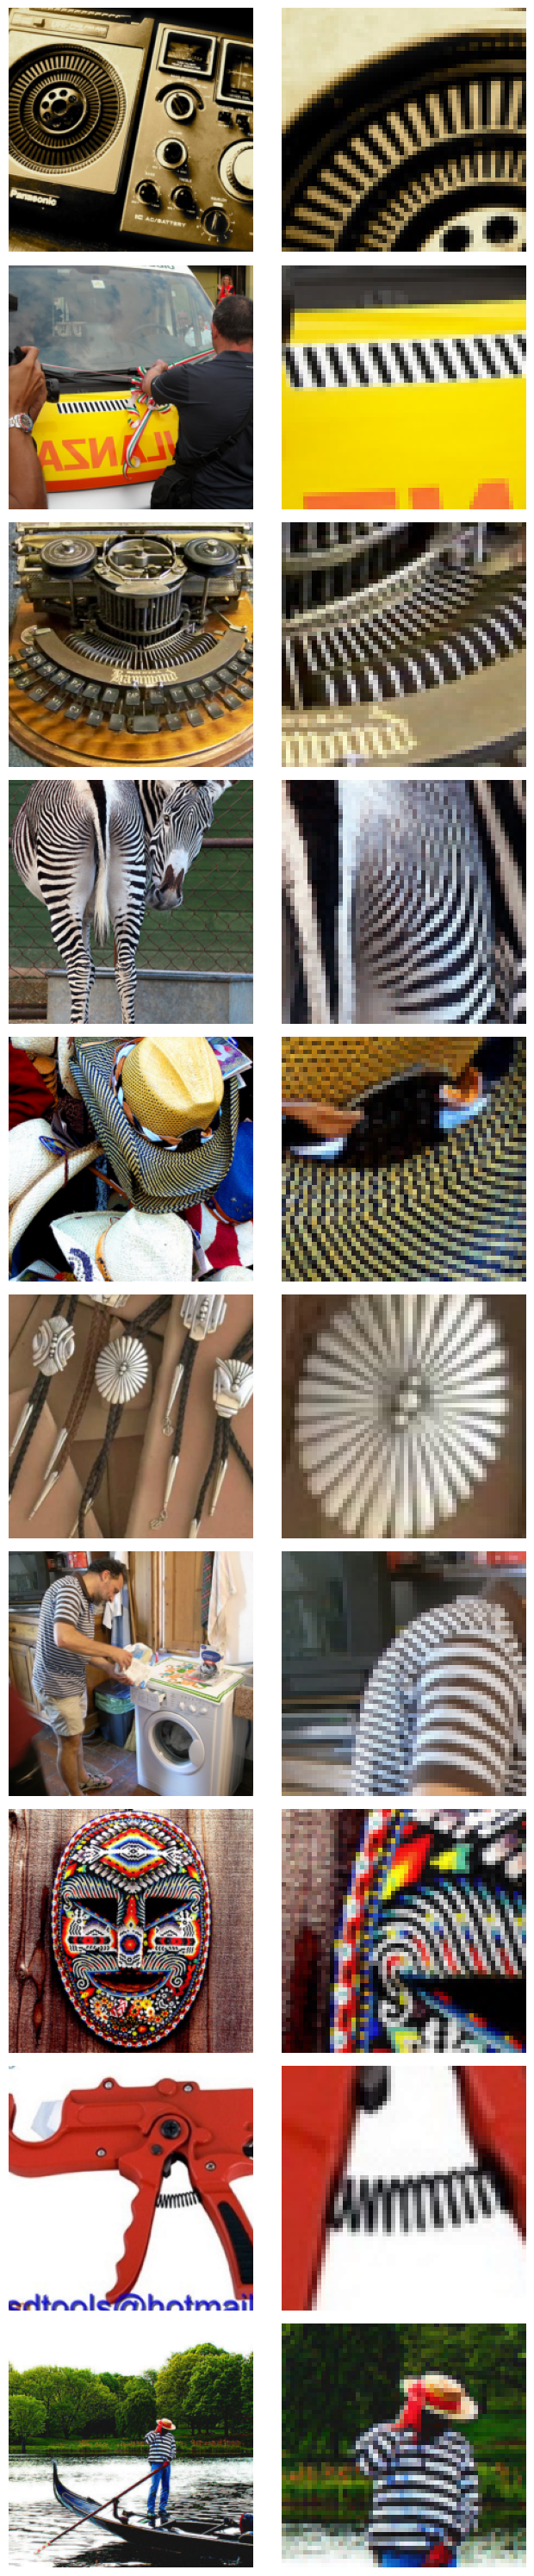

In [32]:
cols = 2
rows = len(top10)
plt.figure(figsize=(7, 3 * rows))

for idx, (s, k, pil_full, pil_crop) in enumerate(top10):
    plt.subplot(rows, cols, 2*idx + 1)
    plt.imshow(pil_full)
    plt.axis("off")

    plt.subplot(rows, cols, 2*idx + 2)
    plt.imshow(pil_crop)
    plt.axis("off")

plt.tight_layout()
plt.show()